# Laboratorio 08 - Procesamiento de Imágenes con OpenCV

**Asignatura:** Computación Gráfica, Visión Computacional y Multimedia  
**Tema:** Procesamiento de imágenes  
**Autor:** Pacori Anccasi Diego Ivan

Este notebook resuelve los siete ejercicios propuestos de la guía del Laboratorio 08. Para que la ejecución sea reproducible, se generan tres imágenes sintéticas a color y de dimensiones diferentes: una persona (720 × 520 px), un gato (430 × 360 px) y un perro (560 × 390 px). A continuación se aplican las operaciones solicitadas con OpenCV, NumPy y Matplotlib, se guardan los resultados y se produce evidencia visual de cada paso.


## 0. Entorno utilizado

El entorno Conda utilizado se llama `lab08-cgvc` y fue registrado como kernel de Jupyter con el nombre visible `Python (lab08-cgvc)`.

Comandos principales:

```powershell
C:\Users\diego\anaconda3\Scripts\conda.exe env create -f environment.yml
C:\Users\diego\anaconda3\Scripts\conda.exe run -n lab08-cgvc python -m ipykernel install --user --name lab08-cgvc --display-name "Python (lab08-cgvc)"
```


In [1]:
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

print("Python:", sys.version.split()[0])
print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", plt.matplotlib.__version__)
print("Pillow:", Image.__version__)

Python: 3.11.15
OpenCV: 4.13.0
NumPy: 2.4.6
Matplotlib: 3.11.0
Pillow: 12.2.0


In [2]:
ROOT = Path.cwd()

# Todos los recursos se guardan junto al notebook para facilitar su visualización.
DATA_DIR = ROOT
RESULTS_DIR = ROOT
CAPTURES_DIR = ROOT

print("Directorio del laboratorio:", ROOT)
print("Las imágenes base, los resultados y las capturas se guardan en esta carpeta.")


Directorio del laboratorio: C:\Users\diego\OneDrive\Desktop\Laboratorio-08-CGVC
Las imágenes base, los resultados y las capturas se guardan en esta carpeta.


## 1. Preparación de las imágenes de entrada

La guía solicita tres imágenes a color que contengan una persona o un animal y que tengan tamaños diferentes. Como el material de entrada no incluía imágenes base, se crean tres escenas sintéticas y reproducibles. El orden se mantiene durante toda la práctica: **imagen 1 = persona**, **imagen 2 = gato** e **imagen 3 = perro**.

Esta preparación no reemplaza los ejercicios: únicamente garantiza que cualquier persona pueda ejecutar el notebook y obtener exactamente las mismas entradas y resultados.


persona: 720x520 px -> C:\Users\diego\OneDrive\Desktop\Laboratorio-08-CGVC\base_persona.png
gato: 430x360 px -> C:\Users\diego\OneDrive\Desktop\Laboratorio-08-CGVC\base_gato.png
perro: 560x390 px -> C:\Users\diego\OneDrive\Desktop\Laboratorio-08-CGVC\base_perro.png


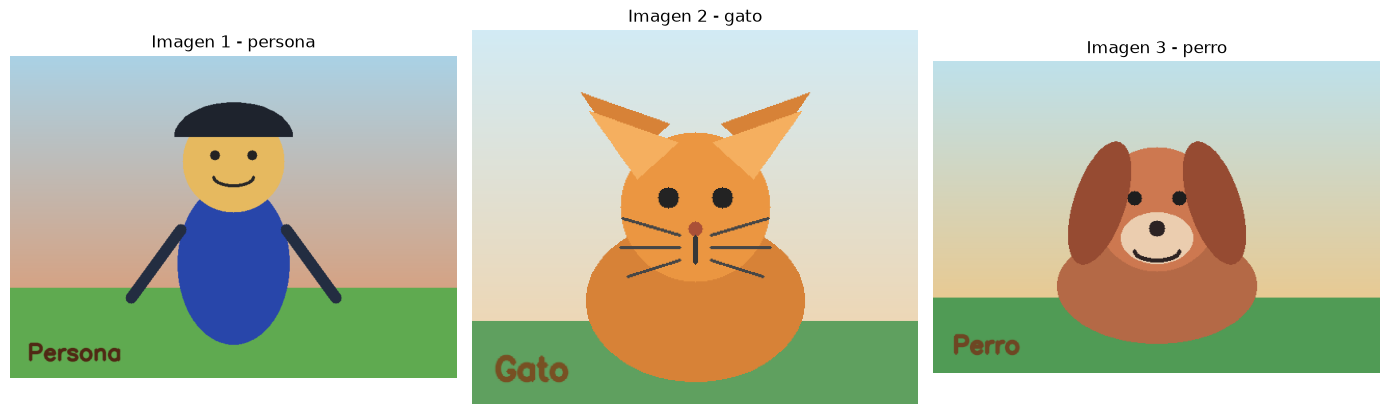

In [3]:
def gradient_background(height, width, top_bgr, bottom_bgr):
    top = np.array(top_bgr, dtype=np.float32)
    bottom = np.array(bottom_bgr, dtype=np.float32)
    alpha = np.linspace(0, 1, height, dtype=np.float32)[:, None, None]
    row = (1 - alpha) * top + alpha * bottom
    return np.repeat(row, width, axis=1).astype(np.uint8)


def draw_person_scene(width=720, height=520):
    img = gradient_background(height, width, (230, 210, 170), (95, 145, 230))
    cv2.rectangle(img, (0, int(height * 0.72)), (width, height), (80, 170, 95), -1)
    cx = width // 2
    # cuerpo y brazos
    cv2.ellipse(img, (cx, 335), (90, 130), 0, 0, 360, (170, 70, 40), -1)
    cv2.line(img, (cx - 85, 280), (cx - 165, 390), (65, 45, 35), 18)
    cv2.line(img, (cx + 85, 280), (cx + 165, 390), (65, 45, 35), 18)
    # rostro, cabello y detalles
    cv2.circle(img, (cx, 170), 82, (95, 185, 230), -1)
    cv2.ellipse(img, (cx, 130), (95, 55), 0, 180, 360, (45, 35, 30), -1)
    cv2.circle(img, (cx - 30, 160), 8, (35, 35, 35), -1)
    cv2.circle(img, (cx + 30, 160), 8, (35, 35, 35), -1)
    cv2.ellipse(img, (cx, 195), (32, 14), 0, 0, 180, (40, 40, 40), 4)
    cv2.putText(img, "Persona", (28, height - 30), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (20, 40, 80), 3, cv2.LINE_AA)
    return img


def draw_cat_scene(width=430, height=360):
    img = gradient_background(height, width, (245, 235, 210), (165, 210, 245))
    cv2.rectangle(img, (0, int(height * 0.78)), (width, height), (95, 160, 95), -1)
    cx, cy = width // 2, height // 2 + 15
    # cuerpo y cabeza
    cv2.ellipse(img, (cx, cy + 65), (105, 78), 0, 0, 360, (55, 130, 215), -1)
    cv2.circle(img, (cx, cy - 25), 72, (65, 150, 235), -1)
    # orejas
    pts1 = np.array([[cx - 64, cy - 70], [cx - 110, cy - 135], [cx - 25, cy - 105]], np.int32)
    pts2 = np.array([[cx + 64, cy - 70], [cx + 110, cy - 135], [cx + 25, cy - 105]], np.int32)
    cv2.fillConvexPoly(img, pts1, (55, 130, 215))
    cv2.fillConvexPoly(img, pts2, (55, 130, 215))
    cv2.fillConvexPoly(img, pts1 + np.array([8, 18]), (95, 175, 245))
    cv2.fillConvexPoly(img, pts2 + np.array([-8, 18]), (95, 175, 245))
    # rostro
    cv2.circle(img, (cx - 26, cy - 34), 10, (35, 35, 35), -1)
    cv2.circle(img, (cx + 26, cy - 34), 10, (35, 35, 35), -1)
    cv2.circle(img, (cx, cy - 4), 7, (55, 80, 170), -1)
    cv2.line(img, (cx, cy + 4), (cx, cy + 28), (55, 55, 55), 3)
    for side in (-1, 1):
        cv2.line(img, (cx + side * 15, cy + 2), (cx + side * 70, cy - 14), (70, 70, 70), 2)
        cv2.line(img, (cx + side * 15, cy + 14), (cx + side * 72, cy + 14), (70, 70, 70), 2)
        cv2.line(img, (cx + side * 15, cy + 26), (cx + side * 65, cy + 42), (70, 70, 70), 2)
    cv2.putText(img, "Gato", (22, height - 24), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (35, 80, 120), 3, cv2.LINE_AA)
    return img


def draw_dog_scene(width=560, height=390):
    img = gradient_background(height, width, (235, 225, 190), (120, 195, 245))
    cv2.rectangle(img, (0, int(height * 0.76)), (width, height), (85, 155, 80), -1)
    cx, cy = width // 2, height // 2 + 8
    # cuerpo, cabeza y orejas
    cv2.ellipse(img, (cx, cy + 78), (125, 72), 0, 0, 360, (70, 105, 180), -1)
    cv2.circle(img, (cx, cy - 18), 78, (80, 120, 205), -1)
    cv2.ellipse(img, (cx - 72, cy - 26), (32, 80), 18, 0, 360, (50, 75, 150), -1)
    cv2.ellipse(img, (cx + 72, cy - 26), (32, 80), -18, 0, 360, (50, 75, 150), -1)
    # hocico y rostro
    cv2.ellipse(img, (cx, cy + 18), (45, 32), 0, 0, 360, (175, 205, 235), -1)
    cv2.circle(img, (cx - 28, cy - 32), 9, (30, 30, 30), -1)
    cv2.circle(img, (cx + 28, cy - 32), 9, (30, 30, 30), -1)
    cv2.circle(img, (cx, cy + 6), 10, (35, 35, 45), -1)
    cv2.ellipse(img, (cx, cy + 34), (28, 12), 0, 0, 180, (35, 35, 45), 3)
    cv2.putText(img, "Perro", (24, height - 25), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (35, 70, 110), 3, cv2.LINE_AA)
    return img


def bgr_to_rgb(img):
    if img.ndim == 2:
        return img
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def show_images(items, cols=3, figsize=(14, 6), save_path=None):
    rows = int(np.ceil(len(items) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    for ax, (title, image) in zip(axes, items):
        if image.ndim == 2:
            ax.imshow(image, cmap="gray", vmin=0, vmax=255)
        else:
            ax.imshow(bgr_to_rgb(image))
        ax.set_title(title)
        ax.axis("off")
    for ax in axes[len(items):]:
        ax.axis("off")
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=140, bbox_inches="tight")
    plt.show()

base_images = {
    "persona": draw_person_scene(),
    "gato": draw_cat_scene(),
    "perro": draw_dog_scene(),
}

base_paths = {}
for name, image in base_images.items():
    path = DATA_DIR / f"base_{name}.png"
    cv2.imwrite(str(path), image)
    base_paths[name] = path
    print(f"{name}: {image.shape[1]}x{image.shape[0]} px -> {path}")

show_images(
    [("Imagen 1 - persona", base_images["persona"]), ("Imagen 2 - gato", base_images["gato"]), ("Imagen 3 - perro", base_images["perro"])],
    save_path=CAPTURES_DIR / "captura_00_imagenes_base.png",
)

## 2. Redimensionamiento sin deformación

La imagen de mayor área (720 × 520 px) define el lienzo objetivo. Para cada imagen se calcula un único factor de escala:

\[
s = \min\left(\frac{W}{w},\frac{H}{h}\right)
\]

Luego se obtienen `w' = round(w·s)` y `h' = round(h·s)`. Como ambos ejes usan el mismo factor, la relación de aspecto se conserva. El contenido se centra y el espacio libre se completa con bordes negros (*letterbox*). Se usa interpolación cúbica al ampliar e interpolación de área al reducir.


Imagen objetivo: persona 720x520
persona: escala=1.000, contenido=720x520, offset=(0, 0), salida=720x520, error_relación=0.0000%
gato: escala=1.444, contenido=621x520, offset=(49, 0), salida=720x520, error_relación=0.0179%
perro: escala=1.286, contenido=720x501, offset=(0, 9), salida=720x520, error_relación=0.0855%


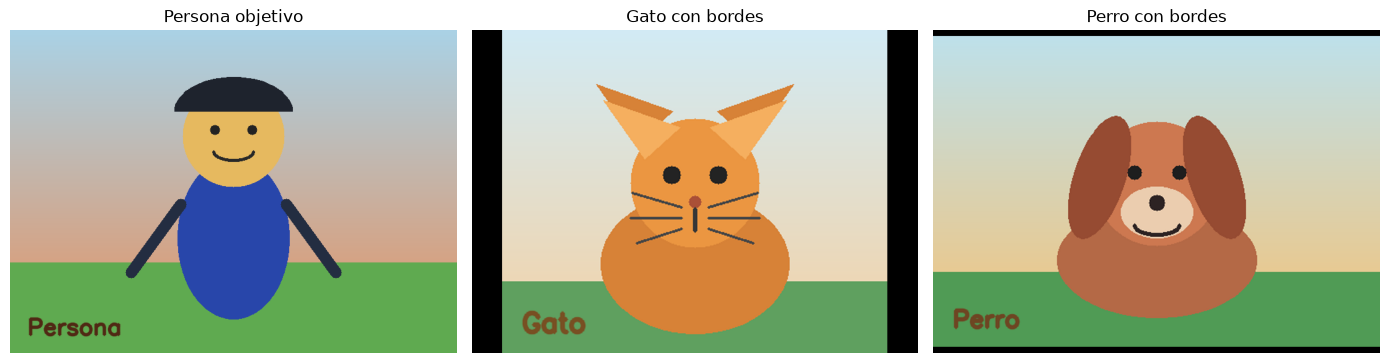

In [4]:
def resize_with_letterbox(image, target_width, target_height, border_color=(0, 0, 0)):
    if image is None or image.size == 0:
        raise ValueError("La imagen de entrada está vacía o no pudo cargarse.")

    h, w = image.shape[:2]
    scale = min(target_width / w, target_height / h)
    new_w = int(round(w * scale))
    new_h = int(round(h * scale))
    if np.isclose(scale, 1.0):
        resized = image.copy()
    else:
        interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_CUBIC
        resized = cv2.resize(image, (new_w, new_h), interpolation=interpolation)

    canvas = np.full((target_height, target_width, 3), border_color, dtype=image.dtype)
    x0 = (target_width - new_w) // 2
    y0 = (target_height - new_h) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized
    return canvas, scale, (x0, y0), (new_w, new_h)


loaded = {name: cv2.imread(str(path)) for name, path in base_paths.items()}
if any(image is None for image in loaded.values()):
    raise FileNotFoundError("No se pudieron cargar todas las imágenes base.")

areas = {name: image.shape[0] * image.shape[1] for name, image in loaded.items()}
target_name = max(areas, key=areas.get)
target_h, target_w = loaded[target_name].shape[:2]
print("Imagen objetivo:", target_name, f"{target_w}x{target_h}")

resized_images = {}
for name, image in loaded.items():
    resized, scale, offset, content_size = resize_with_letterbox(image, target_w, target_h)
    resized_images[name] = resized
    cv2.imwrite(str(RESULTS_DIR / f"resultado_01_{name}_redimensionada.png"), resized)
    source_ratio = image.shape[1] / image.shape[0]
    resized_ratio = content_size[0] / content_size[1]
    ratio_error = abs(resized_ratio - source_ratio) / source_ratio
    print(
        f"{name}: escala={scale:.3f}, contenido={content_size[0]}x{content_size[1]}, "
        f"offset={offset}, salida={resized.shape[1]}x{resized.shape[0]}, "
        f"error_relación={ratio_error:.4%}"
    )

show_images(
    [("Persona objetivo", resized_images["persona"]), ("Gato con bordes", resized_images["gato"]), ("Perro con bordes", resized_images["perro"])],
    save_path=CAPTURES_DIR / "captura_01_redimension_aspect_ratio.png",
)


## 3. Creación de una imagen con canales combinados

OpenCV almacena los canales en orden **BGR**. La consigna pide tomar el canal rojo de la primera imagen, el verde de la segunda y el azul de la tercera; por eso la fusión se realiza como `B = perro`, `G = gato` y `R = persona`. Todas las matrices ya tienen 720 × 520 píxeles gracias al ejercicio anterior.


Imagen combinada guardada en: C:\Users\diego\OneDrive\Desktop\Laboratorio-08-CGVC\resultado_02_canales_combinados.png


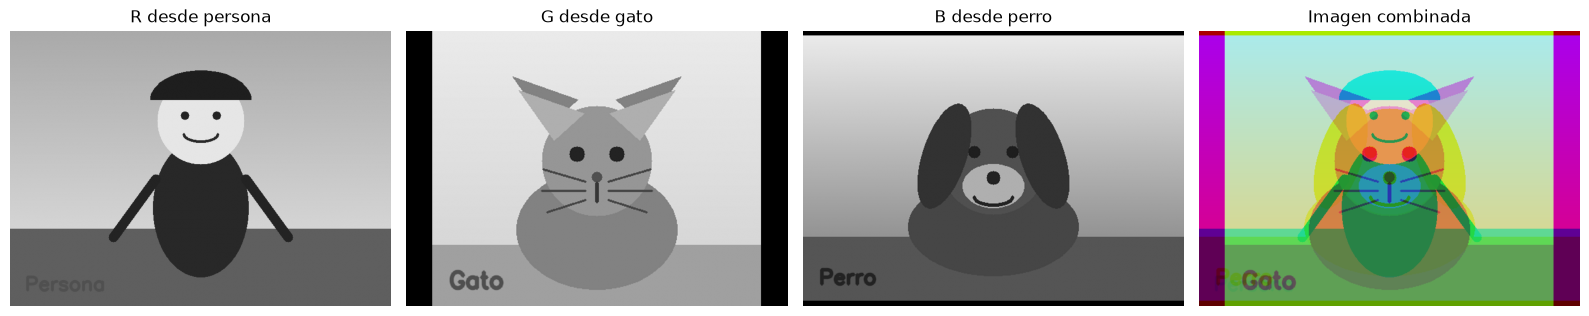

In [5]:
b_persona, g_persona, r_persona = cv2.split(resized_images["persona"])
b_gato, g_gato, r_gato = cv2.split(resized_images["gato"])
b_perro, g_perro, r_perro = cv2.split(resized_images["perro"])

combined = cv2.merge([b_perro, g_gato, r_persona])
combined_path = RESULTS_DIR / "resultado_02_canales_combinados.png"
cv2.imwrite(str(combined_path), combined)
print("Imagen combinada guardada en:", combined_path)

show_images(
    [
        ("R desde persona", r_persona),
        ("G desde gato", g_gato),
        ("B desde perro", b_perro),
        ("Imagen combinada", combined),
    ],
    cols=4,
    figsize=(16, 4),
    save_path=CAPTURES_DIR / "captura_02_canales_combinados.png",
)

## 4. Conversión a negativo y escala de grises

El negativo invierte cada intensidad mediante `I_neg = 255 - I`. `cv2.bitwise_not` aplica esta operación a los tres canales. Después, la imagen negativa se convierte a una matriz de una sola intensidad con `cv2.cvtColor(..., cv2.COLOR_BGR2GRAY)`, que pondera los canales aproximadamente como `0.114B + 0.587G + 0.299R`. Ambas salidas se guardan en formato PNG.


Negativo: C:\Users\diego\OneDrive\Desktop\Laboratorio-08-CGVC\resultado_03_negativo.png
Escala de grises: C:\Users\diego\OneDrive\Desktop\Laboratorio-08-CGVC\resultado_03_negativo_grises.png


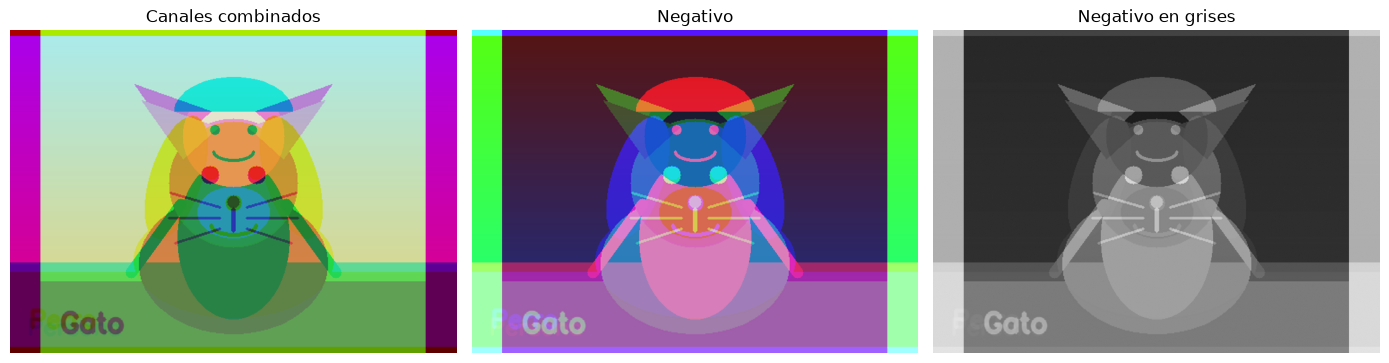

In [6]:
negative = cv2.bitwise_not(combined)
gray_negative = cv2.cvtColor(negative, cv2.COLOR_BGR2GRAY)

negative_path = RESULTS_DIR / "resultado_03_negativo.png"
gray_path = RESULTS_DIR / "resultado_03_negativo_grises.png"
cv2.imwrite(str(negative_path), negative)
cv2.imwrite(str(gray_path), gray_negative)

print("Negativo:", negative_path)
print("Escala de grises:", gray_path)

show_images(
    [("Canales combinados", combined), ("Negativo", negative), ("Negativo en grises", gray_negative)],
    cols=3,
    figsize=(14, 5),
    save_path=CAPTURES_DIR / "captura_03_negativo_y_grises.png",
)

## 5. Aplicación interactiva para visualizar canales

La función `filter_channels` conserva o anula cada canal mediante indicadores booleanos. La aplicación interactiva muestra la imagen en una ventana y usa `r`, `g` y `b` para alternar rojo, verde y azul; `q` o `Esc` cierran la ventana.

La ejecución automática del notebook no abre ventanas bloqueantes. La evidencia se genera llamando a la misma función de filtrado con seis combinaciones de estado, mientras que `channel_viewer_interactive(combined_path)` queda disponible para una prueba manual.


Función interactiva creada: channel_viewer_interactive(combined_path)
Teclas: r alterna rojo, g alterna verde, b alterna azul, q sale.


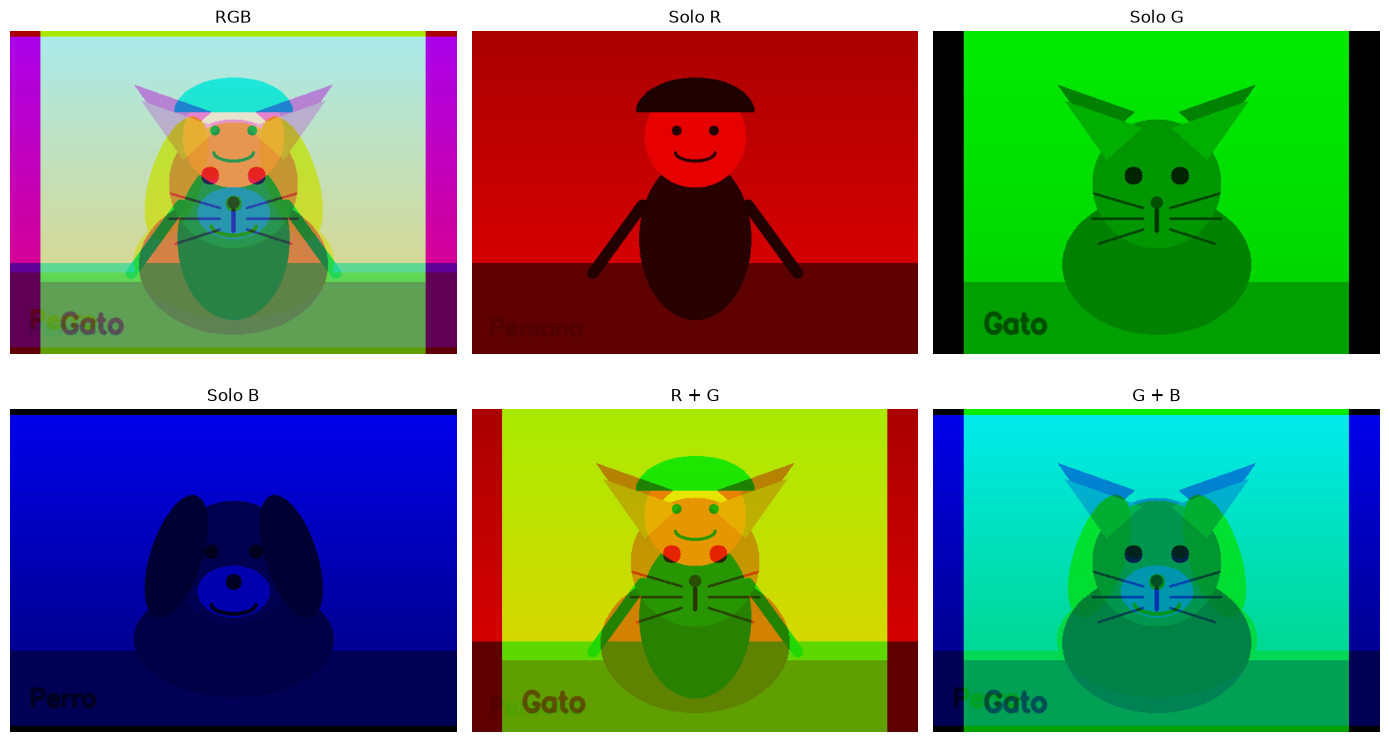

In [7]:
def filter_channels(image_bgr, show_red=True, show_green=True, show_blue=True):
    filtered = image_bgr.copy()
    if not show_blue:
        filtered[:, :, 0] = 0
    if not show_green:
        filtered[:, :, 1] = 0
    if not show_red:
        filtered[:, :, 2] = 0
    return filtered


def channel_viewer_interactive(image_path):
    # Ejecutar manualmente en PowerShell/Jupyter local: r, g, b alternan canales; q sale.
    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(image_path)
    show_red = show_green = show_blue = True
    window = "Visor de canales - r/g/b alternan, q sale"
    cv2.namedWindow(window, cv2.WINDOW_NORMAL)
    try:
        while True:
            view = filter_channels(image, show_red, show_green, show_blue)
            cv2.imshow(window, view)
            key = cv2.waitKey(30) & 0xFF
            if key == ord("r"):
                show_red = not show_red
            elif key == ord("g"):
                show_green = not show_green
            elif key == ord("b"):
                show_blue = not show_blue
            elif key == ord("q") or key == 27:
                break
    finally:
        cv2.destroyAllWindows()

channel_states = [
    ("RGB", True, True, True),
    ("Solo R", True, False, False),
    ("Solo G", False, True, False),
    ("Solo B", False, False, True),
    ("R + G", True, True, False),
    ("G + B", False, True, True),
]
state_images = [(title, filter_channels(combined, r, g, b)) for title, r, g, b in channel_states]
for title, img in state_images:
    filename = title.lower().replace(" ", "_").replace("+", "mas")
    cv2.imwrite(str(RESULTS_DIR / f"resultado_04_canales_{filename}.png"), img)

print("Función interactiva creada: channel_viewer_interactive(combined_path)")
print("Teclas: r alterna rojo, g alterna verde, b alterna azul, q sale.")

show_images(
    state_images,
    cols=3,
    figsize=(14, 8),
    save_path=CAPTURES_DIR / "captura_04_visor_canales_simulado.png",
)


## 6. Dibujo de figuras y texto sobre una imagen

Se copia la imagen de la persona, se marca manualmente el rostro con un círculo y se añaden dos textos descriptivos. OpenCV usa el origen de coordenadas en la esquina superior izquierda y recibe los colores en orden BGR. Las funciones principales son `cv2.circle` y `cv2.putText`.


Imagen anotada: C:\Users\diego\OneDrive\Desktop\Laboratorio-08-CGVC\resultado_05_persona_anotada.png


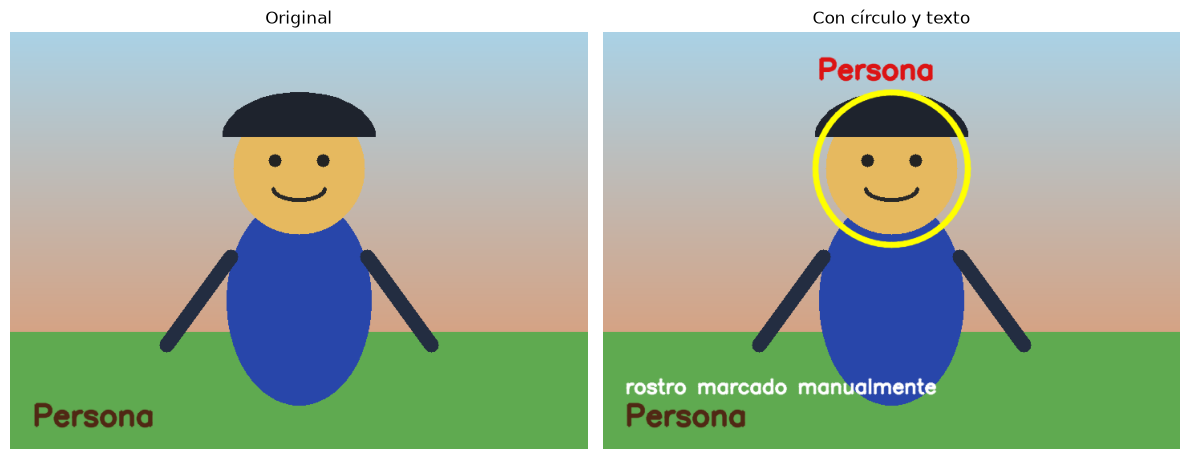

In [8]:
annotated = loaded["persona"].copy()
face_center = (annotated.shape[1] // 2, 170)
cv2.circle(annotated, face_center, 95, (0, 255, 255), 6, cv2.LINE_AA)
cv2.putText(annotated, "Persona", (face_center[0] - 92, face_center[1] - 112), cv2.FONT_HERSHEY_SIMPLEX, 1.15, (20, 20, 220), 3, cv2.LINE_AA)
cv2.putText(annotated, "rostro marcado manualmente", (28, annotated.shape[0] - 70), cv2.FONT_HERSHEY_SIMPLEX, 0.82, (255, 255, 255), 2, cv2.LINE_AA)

annotated_path = RESULTS_DIR / "resultado_05_persona_anotada.png"
cv2.imwrite(str(annotated_path), annotated)
print("Imagen anotada:", annotated_path)

show_images(
    [("Original", loaded["persona"]), ("Con círculo y texto", annotated)],
    cols=2,
    figsize=(12, 5),
    save_path=CAPTURES_DIR / "captura_05_figuras_y_texto.png",
)


## 7. Aplicación de umbral binario

Primero se transforma la imagen combinada a escala de grises. Para el umbral fijo `T = 127`, cada píxel se convierte en blanco si `I > T` y en negro en caso contrario. También se calcula un segundo resultado con Otsu, que selecciona automáticamente el valor que minimiza la variación dentro de las dos clases. En esta ejecución Otsu obtiene `T = 152`.


Umbral fijo: 127 -> C:\Users\diego\OneDrive\Desktop\Laboratorio-08-CGVC\resultado_06_threshold_binario_127.png
Umbral Otsu calculado: 152.0 -> C:\Users\diego\OneDrive\Desktop\Laboratorio-08-CGVC\resultado_06_threshold_binario_otsu.png


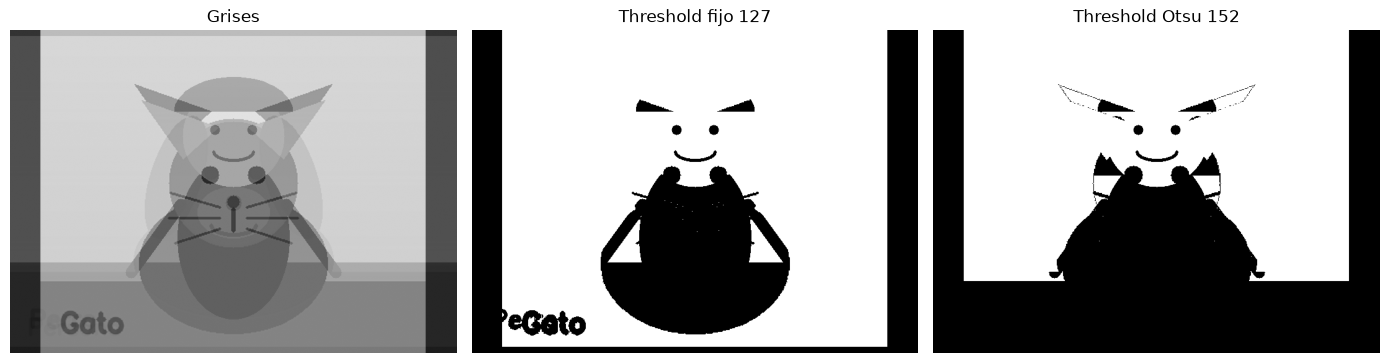

In [9]:
gray_for_threshold = cv2.cvtColor(combined, cv2.COLOR_BGR2GRAY)
fixed_threshold_value = 127
_, binary_fixed = cv2.threshold(gray_for_threshold, fixed_threshold_value, 255, cv2.THRESH_BINARY)
otsu_value, binary_otsu = cv2.threshold(gray_for_threshold, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

fixed_path = RESULTS_DIR / "resultado_06_threshold_binario_127.png"
otsu_path = RESULTS_DIR / "resultado_06_threshold_binario_otsu.png"
cv2.imwrite(str(fixed_path), binary_fixed)
cv2.imwrite(str(otsu_path), binary_otsu)

print("Umbral fijo:", fixed_threshold_value, "->", fixed_path)
print("Umbral Otsu calculado:", round(float(otsu_value), 2), "->", otsu_path)

show_images(
    [("Grises", gray_for_threshold), ("Threshold fijo 127", binary_fixed), (f"Threshold Otsu {otsu_value:.0f}", binary_otsu)],
    cols=3,
    figsize=(14, 5),
    save_path=CAPTURES_DIR / "captura_06_threshold_binario.png",
)

## 8. Programa de dibujo interactivo con mouse y teclado

`DrawingApp` mantiene el lienzo, el modo activo y una pila de estados para deshacer. El usuario fija el punto inicial con `EVENT_LBUTTONDOWN` y completa la figura con `EVENT_LBUTTONUP`. Las teclas `r`, `c` y `l` seleccionan rectángulo, círculo y línea; `u` deshace, `s` guarda y `q`/`Esc` cierra.

Para dejar evidencia sin abrir una ventana, la demostración utiliza los propios métodos `draw_shape`, `undo` y `save` de la clase. Por tanto, la captura y el archivo final ya no proceden de una simulación independiente.


Clase interactiva lista: app = DrawingApp(); app.run()
Prueba de deshacer: correcta
Evidencia generada por DrawingApp: C:\Users\diego\OneDrive\Desktop\Laboratorio-08-CGVC\resultado_07_dibujo_interactivo.png


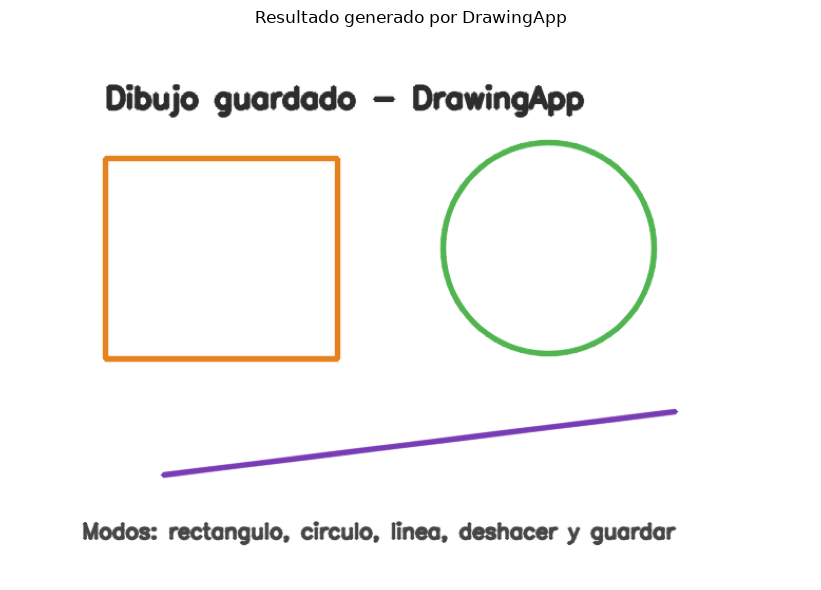

In [10]:
class DrawingApp:
    def __init__(self, width=900, height=620, save_path=RESULTS_DIR / "resultado_07_dibujo_interactivo.png"):
        self.canvas = np.full((height, width, 3), 255, dtype=np.uint8)
        self.mode = "rectangle"
        self.start = None
        self.history = []
        self.save_path = Path(save_path)
        self.window = "Dibujo interactivo - r/c/l modo, u deshacer, s guardar, q salir"

    def push_history(self):
        self.history.append(self.canvas.copy())
        if len(self.history) > 20:
            self.history.pop(0)

    def undo(self):
        if self.history:
            self.canvas = self.history.pop()

    def draw_shape(self, start, end):
        self.push_history()
        if self.mode == "rectangle":
            cv2.rectangle(self.canvas, start, end, (30, 130, 230), 3, cv2.LINE_AA)
        elif self.mode == "circle":
            radius = int(np.hypot(end[0] - start[0], end[1] - start[1]))
            cv2.circle(self.canvas, start, radius, (80, 180, 80), 3, cv2.LINE_AA)
        elif self.mode == "line":
            cv2.line(self.canvas, start, end, (180, 60, 120), 4, cv2.LINE_AA)

    def on_mouse(self, event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN:
            self.start = (x, y)
        elif event == cv2.EVENT_LBUTTONUP and self.start is not None:
            self.draw_shape(self.start, (x, y))
            self.start = None

    def save(self):
        self.save_path.parent.mkdir(parents=True, exist_ok=True)
        if not cv2.imwrite(str(self.save_path), self.canvas):
            raise OSError(f"No se pudo guardar el dibujo en {self.save_path}")
        return self.save_path

    def render_overlay(self):
        view = self.canvas.copy()
        help_text = f"Modo: {self.mode} | r rect | c circ | l linea | u deshacer | s guardar | q salir"
        cv2.rectangle(view, (0, 0), (view.shape[1], 44), (245, 245, 245), -1)
        cv2.putText(view, help_text, (16, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.74, (35, 35, 35), 2, cv2.LINE_AA)
        return view

    def run(self):
        cv2.namedWindow(self.window, cv2.WINDOW_NORMAL)
        cv2.setMouseCallback(self.window, self.on_mouse)
        while True:
            cv2.imshow(self.window, self.render_overlay())
            key = cv2.waitKey(20) & 0xFF
            if key == ord("r"):
                self.mode = "rectangle"
            elif key == ord("c"):
                self.mode = "circle"
            elif key == ord("l"):
                self.mode = "line"
            elif key == ord("u"):
                self.undo()
            elif key == ord("s"):
                print("Dibujo guardado en", self.save())
            elif key == ord("q") or key == 27:
                break
        cv2.destroyAllWindows()


# Demostración no interactiva usando la misma clase y los mismos métodos.
demo = DrawingApp(width=760, height=520)
demo.mode = "rectangle"
demo.draw_shape((90, 120), (310, 310))
demo.mode = "circle"
demo.draw_shape((510, 205), (610, 205))
demo.mode = "line"
demo.draw_shape((145, 420), (630, 360))

# Verificación automática de la opción de deshacer.
state_before_undo_test = demo.canvas.copy()
demo.draw_shape((20, 20), (200, 20))
demo.undo()
assert np.array_equal(demo.canvas, state_before_undo_test)

cv2.putText(demo.canvas, "Dibujo guardado - DrawingApp", (90, 72), cv2.FONT_HERSHEY_SIMPLEX, 0.92, (45, 45, 45), 3, cv2.LINE_AA)
cv2.putText(demo.canvas, "Modos: rectangulo, circulo, linea, deshacer y guardar", (68, 480), cv2.FONT_HERSHEY_SIMPLEX, 0.66, (70, 70, 70), 2, cv2.LINE_AA)
drawing_path = demo.save()

print("Clase interactiva lista: app = DrawingApp(); app.run()")
print("Prueba de deshacer: correcta")
print("Evidencia generada por DrawingApp:", drawing_path)

show_images(
    [("Resultado generado por DrawingApp", demo.canvas)],
    cols=1,
    figsize=(10, 6),
    save_path=CAPTURES_DIR / "captura_07_dibujo_interactivo.png",
)


## 9. Avance individual del proyecto grupal

Los materiales disponibles no identifican el nombre del proyecto grupal, la tarea formalmente asignada ni un repositorio de integración. Para evitar inventar información, se registran únicamente los artefactos verificables desarrollados en este laboratorio y se deja explícito qué dato debe completarse antes de la entrega.

| Estado | Avance individual verificable | Evidencia |
|---|---|---|
| Completado | Preparación del entorno reproducible y del kernel de Jupyter. | `environment.yml` y notebook ejecutado. |
| Completado | Implementación del flujo de carga, redimensionamiento, combinación de canales, negativo, grises y umbral. | Celdas 1-7 y archivos con prefijo `resultado_`. |
| Completado | Prototipos interactivos para alternar canales y dibujar figuras con deshacer/guardar. | `channel_viewer_interactive` y `DrawingApp`. |
| Pendiente de dato | Relación de estos artefactos con la tarea asignada dentro del proyecto grupal. | Completar nombre del proyecto, tarea, enlace/commit y estado de integración. |


## 10. Cuestionario

**1. ¿Qué otros modelos o espacios de color existen para las imágenes?**  
Además de RGB/BGR, se emplean HSV y HSL para separar tono, saturación y luminosidad; CIE LAB y Luv para trabajar con diferencias perceptuales de color; YCrCb/YCbCr para separar luminancia y crominancia en video y compresión; XYZ como espacio de referencia colorimétrico; y CMYK en procesos de impresión. La escala de grises no representa color, pero es útil cuando basta una sola medida de intensidad.

**2. ¿Qué otros cambios se pueden realizar a las imágenes con OpenCV?**  
OpenCV permite transformaciones geométricas (recorte, rotación, traslación y perspectiva), ajustes de intensidad y color, suavizado y reducción de ruido, realce y detección de bordes, ecualización de histograma, operaciones morfológicas, segmentación, detección de contornos, composición de imágenes y extracción de características. La operación apropiada depende del problema y de la información que se desea conservar.

**3. ¿Cuál sería el uso del *binary threshold* en el procesamiento de imágenes?**  
El umbral binario convierte una imagen de intensidad en una máscara de dos clases. Se utiliza para separar objetos del fondo, digitalizar documentos, aislar siluetas, contar componentes y preparar una imagen antes de calcular contornos u otras mediciones. Funciona mejor cuando las intensidades de las dos regiones están bien separadas; si la iluminación varía, puede ser preferible un umbral adaptativo u Otsu.


## 11. Archivos generados

- Imágenes base: `base_persona.png`, `base_gato.png` y `base_perro.png`.
- Resultados numéricos y visuales: archivos con prefijo `resultado_`.
- Capturas utilizadas en el informe: archivos con prefijo `captura_`.
- Funciones interactivas listas para ejecución manual:
  - `channel_viewer_interactive(combined_path)`
  - `app = DrawingApp(); app.run()`
